In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pytspl.simplicial_complex import SCBuilder
from pytspl.embeddings.k_simplex2vec import cell2vec
from sklearn.cluster import KMeans

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, rand_score
from collections import Counter
from pytspl.embeddings.k_simplex2vec import _k_cell_adjacency


In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pytspl.simplicial_complex import SCBuilder
from pytspl.embeddings.k_simplex2vec import cell2vec

# ------------------------------------------------------------
# 1. Build the same SBM graph she uses
# ------------------------------------------------------------
n = 20
q = 0.3
p = 0.8
probs = [[p, q, q],
         [q, p, q],
         [q, q, p]]

G = nx.generators.community.stochastic_block_model(
    [n, n, n],
    probs,
    seed=2342,
)

# ------------------------------------------------------------
# 2. Build a simplicial complex using your SCBuilder
#    (equivalent to Gudhi SimplexTree + expansion(3))
# ------------------------------------------------------------
nodes = list(G.nodes())
edges = list(G.edges())

sc_builder = SCBuilder(
    nodes=nodes,
    edges=edges,
    node_features={},
    edge_features={},
)

# Build clique complex up to dimension 2
sc = sc_builder.to_simplicial_complex(condition="all")
print(
    f"There are {len(sc.nodes)} nodes, "
    f"{len(sc.edges)} edges, "
    f"{len(sc.triangles)} triangles."
)

There are 60 nodes, 808 edges, 3528 triangles.


In [12]:
from sklearn.cluster import KMeans

emb_dim = 30
k = 1          # 0 = nodes, 1 = edges, 2 = triangles
walk_length = 20
number_walks = 40

embeddings = cell2vec(
    cc=sc,
    k=k,
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme="uniform",
    laziness=None,
    seed=3,
)



KeyboardInterrupt: 

Unique edge types (block pairs): [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
Number of edge types: 6
Counts per type: Counter({(1, 1): 154, (0, 0): 152, (2, 2): 152, (1, 2): 122, (0, 1): 117, (0, 2): 111})
Adjusted Rand Index between KMeans(k=6) and true edge-types: 0.350, Rand Score: 0.808


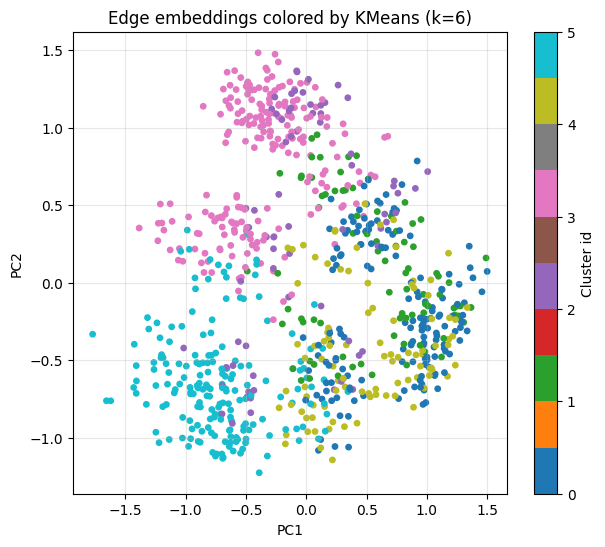

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, rand_score
from collections import Counter


partitions = G.graph["partition"]     # list of 3 groups (block 0,1,2)

# Build mapping node_id -> block_id
block = {}
for b, nodes_block in enumerate(partitions):
    for node in nodes_block:
        block[node] = b

edge_types = []
for (u, v) in sc.edges:
    a = block[u]
    b = block[v]
    # treat (a,b) same as (b,a)
    edge_types.append(tuple(sorted((a, b))))

# map each (block_a, block_b) pair to an integer 0..5
unique_types = sorted(set(edge_types))  # should have 6 entries

print("Unique edge types (block pairs):", unique_types)
print("Number of edge types:", len(unique_types))  # expect 6
print("Counts per type:", Counter(edge_types))

type_to_id = {t: i for i, t in enumerate(unique_types)}
y_true = np.array([type_to_id[t] for t in edge_types])  # shape (#edges,)


pca = PCA(n_components=2, random_state=0)
emb_2d = pca.fit_transform(embeddings)

n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels_pred = kmeans.fit_predict(embeddings)

ari = adjusted_rand_score(y_true, labels_pred)
ri = rand_score(y_true, labels_pred)
print(f"Adjusted Rand Index between KMeans(k=6) and true edge-types: {ari:.3f}, Rand Score: {ri:.3f}")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_pred, s=15, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Edge embeddings colored by KMeans (k=6)")
plt.grid(alpha=0.3)
plt.colorbar(scatter, label="Cluster id")
plt.show()


In [ ]:
from pytspl.embeddings.k_simplex2vec import _k_cell_adjacency
# degrees in edge adjacency
A = _k_cell_adjacency(sc, k=1, multicount=False)
deg = np.array(A.sum(axis=1)).ravel()
print("Edge degree stats: min", deg.min(), "max", deg.max(), "mean", deg.mean())


Edge degree stats: min 41.0 max 65.0 mean 52.551980198019805


In [ ]:
# 2-class labels: 0 = intra, 1 = inter
y_true_2 = np.array([0 if t[0] == t[1] else 1 for t in edge_types])

kmeans2 = KMeans(n_clusters=2, random_state=0)
labels2 = kmeans2.fit_predict(embeddings)

from sklearn.metrics import rand_score, adjusted_rand_score
print("2-class RI:", rand_score(y_true_2, labels2))
print("2-class ARI:", adjusted_rand_score(y_true_2, labels2))


2-class RI: 0.535822076631455
2-class ARI: 0.07147127434020231


SBM Graph:
Nodes: 120
Edges: 3347

CellComplex from SCBuilder:
Nodes: 120
Edges: 3347
Triangles: 31092

Embeddings shape: (120, 20)

Node2vec-like test results:
ARI = 1.000
RI  = 1.000


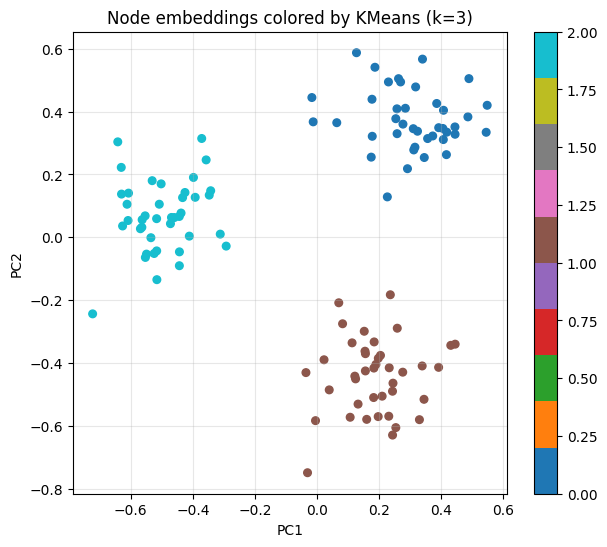

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, rand_score

from pytspl.simplicial_complex import SCBuilder
from pytspl.embeddings.k_simplex2vec import cell2vec


n = 40
p = 0.8
q = 0.3
probs = [[p, q, q],
         [q, p, q],
         [q, q, p]]

G = nx.stochastic_block_model([n, n, n], probs, seed=42)

print("SBM Graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


nodes = list(G.nodes())
edges = list(G.edges())

sc_builder = SCBuilder(nodes=nodes, edges=edges)
sc = sc_builder.to_simplicial_complex(condition="all")  
# or condition="all" — for k=0 it's irrelevant

print("\nCellComplex from SCBuilder:")
print("Nodes:", len(sc.nodes))
print("Edges:", len(sc.edges))
print("Triangles:", len(sc.triangles))


emb_dim = 20
walk_length = 30
number_walks = 50

embeddings = cell2vec(
    cc=sc,
    k=0,                 
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme="uniform",
    seed=123,
    laziness=None
)

print("\nEmbeddings shape:", embeddings.shape)


partitions = G.graph["partition"]   # 3 lists of node IDs

node_to_block = {}
for b, part in enumerate(partitions):
    for u in part:
        node_to_block[u] = b

# Put nodes in the order of sc.nodes
y_true = np.array([node_to_block[u] for u in sc.nodes])


pca = PCA(n_components=2, random_state=0)
emb_2d = pca.fit_transform(embeddings)


kmeans = KMeans(n_clusters=3, random_state=0)
labels_pred = kmeans.fit_predict(embeddings)

ari = adjusted_rand_score(y_true, labels_pred)
ri = rand_score(y_true, labels_pred)

print(f"\nNode2vec-like test results:")
print(f"ARI = {ari:.3f}")
print(f"RI  = {ri:.3f}")


plt.figure(figsize=(7,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels_pred, s=30, cmap="tab10")
plt.title("Node embeddings colored by KMeans (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar()
plt.show()


In [ ]:
from collections import Counter

A = _k_cell_adjacency(sc, k=1, multicount=False)  # uniform adjacency
A = A.tocsr()

# mapping from edge index -> (u,v) and -> type
edge_list = list(sc.edges)
edge_type_ids = y_true          # from earlier (0..5)
edge_type_pairs = unique_types  # list of (block_a, block_b) per type ID

def inspect_edge_neighbors(idx, max_neighbors=15):
    u, v = edge_list[idx]
    t_id = edge_type_ids[idx]
    t_pair = edge_type_pairs[t_id]
    print(f"Edge #{idx}: ({u}, {v}), type {t_id} = {t_pair}")

    row = A.getrow(idx).toarray().ravel()
    neigh_idxs = np.where(row > 0)[0]

    print(f"  degree: {len(neigh_idxs)}")
    neigh_types = edge_type_ids[neigh_idxs]
    counts = Counter(neigh_types)
    print("  neighbor type counts (type_id: count, (block_pair)):")
    for t, c in counts.items():
        print(f"    {t}: {c}  ({edge_type_pairs[t]})")

    # Optionally print a few neighbors
    print("  first few neighbors:")
    for j in neigh_idxs[:max_neighbors]:
        u2, v2 = edge_list[j]
        print(f"    -> edge #{j}: ({u2},{v2}), type {edge_type_ids[j]} ({edge_type_pairs[edge_type_ids[j]]})")

# inspect a few edges of each class
for t_id in range(len(unique_types)):
    idxs = np.where(edge_type_ids == t_id)[0]
    print("\n=== Sample edge of type", t_id, edge_type_pairs[t_id], "===")
    if len(idxs) == 0:
        print("  none of this type")
        continue
    inspect_edge_neighbors(int(idxs[0]))


NameError: name 'unique_types' is not defined